In [1]:
%%capture
%pip install qldpc
%pip install matplotlib

## Combined memory experiments

Rather than computing the error rates of X-type and Z-type logical operators independently, we can run simulations that estimate the error rates of _all_ logical observables in one go.  These simulations are "unphysical" because they rely on the use of perfectly noiseless ancilla qubits.  But nothing stops us from instantiating noiseless ancilla qubits in silico!

For CSS codes such as the toric and surface codes, these simulations require us to do a bit of extra work to split simulation data into X and Z sectors that can be decoded independently.  Below, we provide a function to show how all of this works.

### imports, simulation, and plotting code

In [2]:
import os
from collections.abc import Sequence

import matplotlib.pyplot as plt
import numpy as np
import sinter
from sympy.abc import x, y

from qldpc import circuits, codes, decoders

from common import get_label

%matplotlib inline

In [3]:
def run_combined_memory_experiments(
    codes_to_simulate: Sequence[codes.QuditCode],
    error_rates: Sequence[float] = list(np.logspace(-3, -2, 5)),
    max_shots: int = 10**5,
    max_errors: int = 100,
    distance_trials: int = 100,
    **decoding_kwargs: object,
) -> list[sinter.TaskStats]:
    """Use sinter to simulate memory cycles of the given codes.

    This function ...
      1. Builds a memory experiment for each code.
      2. Adds a depolarizing noise to all gates, at the provided error rates.
      2. Wraps each noisy circuit in a `sinter.Task``.
      3. Runs batched Monte Carlo sampling with `sinter.collect`.

    Args:
        codes_to_simulate: The codes we wish to simulate.
        error_rates: The i.i.d. probabilities of a depolarizing error after each gate.
        max_shots: Stop sampling the circuit after this many shots.
        max_errors: Stops the sampling process after this many errors have been seen in samples
            taken from the circuit.
        distance_trials: If the code distance is not known, estimate it with this many trials.
            The estimated distance determines the number of rounds of syndrome measurement.
        **decoding_kwargs: Arguments to pass to the decoder.

    Returns:
        A `sinter` stats object aggregating shots, errors, and metadata for downstream plotting.
    """
    noise_models = {
        prob: circuits.DepolarizingNoiseModel(prob, include_idling_error=False)
        for prob in error_rates
    }

    tasks = []
    custom_decoders = {}  # each code is going to need its own decoder
    for code_index, code in enumerate(codes_to_simulate):
        distance = code.get_distance(bound=distance_trials)

        # Collect the components of the memory experiment.  In particular, we will need the record
        # of detectors and qubit indices.
        initialization, qec_cycle, readout, measurement_record, detector_record, qubit_ids = (
            circuits.get_memory_experiment_parts(code, basis=None, num_rounds=distance)
        )

        # Identify detectors associated with X-type and Z-type stabilizers (parity checks).
        detectors_x = detector_record.get_events(*qubit_ids.checks_x)
        detectors_z = detector_record.get_events(*qubit_ids.checks_z)

        # Build a decoder that separately decodes X and Z sectors to predict X and Z observables.
        # Here X observables are numbered 0, 1, ..., code.dimension - 1, and Z observables are
        # numbered code.dimension, code.dimension + 1, ..., code.dimension * 2 - 1.
        decoder = decoders.SubgraphDecoder(
            (detectors_x, detectors_z),  # X/Z detectors
            (range(code.dimension), range(code.dimension, 2 * code.dimension)),  # X/Z observables
            **decoding_kwargs,
        )
        decoder_name = f"decoder_{code_index}"
        custom_decoders[decoder_name] = decoder

        for prob in error_rates:
            noise_model = noise_models[prob]
            noisy_circuit = initialization + noise_model.noisy_circuit(qec_cycle) + readout
            tasks.append(
                sinter.Task(
                    circuit=noisy_circuit,
                    decoder=decoder_name,
                    json_metadata={"label": get_label(code), "prob": prob},
                )
            )

    return sinter.collect(
        num_workers=os.cpu_count() - 2,
        max_shots=max_shots,
        max_errors=max_errors,
        tasks=tasks,
        custom_decoders=custom_decoders,
    )


def make_combined_memory_experiment_figure(
    codes_to_simulate: Sequence[codes.QuditCode],
    error_rates: Sequence[float] = list(np.logspace(-3, -2, 5)),
    max_shots: int = 10**5,
    max_errors: int = 100,
    distance_trials: int = 100,
    figsize: tuple[int, int] = (5, 4),
    **decoding_kwargs: object,
) -> tuple[plt.Figure, plt.Axes]:
    """Use sinter to simulate memory cycles of the given codes, and plot the results.

    Args:
        codes_to_simulate: The codes we wish to simulate.
        error_rates: The i.i.d. probabilities of a depolarizing error after each gate.
        max_shots: Stop sampling the circuit after this many shots.
        max_errors: Stops the sampling process after this many errors have been seen in samples
            taken from the circuit.
        distance_trials: If the code distance is not known, estimate it with this many trials.
            The estimated distance determines the number of rounds of syndrome measurement.
        figsize: The size of the figure to produce.
        **decoding_kwargs: Arguments to pass to the decoder.

    Returns:
        The matplotlib.pyplot figure and axis.
    """
    stats = run_combined_memory_experiments(
        codes_to_simulate, error_rates, max_shots, max_errors, distance_trials, **decoding_kwargs
    )

    figure, axis = plt.subplots(figsize=figsize)
    sinter.plot_error_rate(
        ax=axis,
        stats=stats,
        x_func=lambda stats: stats.json_metadata["prob"],
        group_func=lambda stats: stats.json_metadata["label"],
    )

    axis.axline(
        (0, 0),
        slope=1,
        color="k",
        linestyle=":",
        label=r"$p_{\mathrm{log}}=p_{\mathrm{phys}}$",
    )
    axis.loglog()
    axis.set_xlabel(r"physical error rate")
    axis.set_ylabel(r"logical error rate")
    axis.legend(loc="best")
    axis.grid(which="both")
    figure.tight_layout()

    return figure, axis

### Surface code

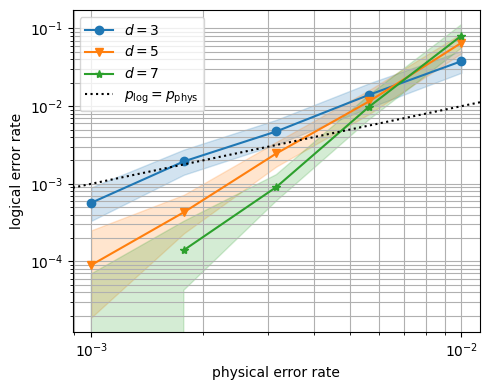

In [4]:
codes_to_simulate = [codes.SurfaceCode(dist, rotated=True) for dist in (3, 5, 7)]
make_combined_memory_experiment_figure(codes_to_simulate, with_MWPM=True)
plt.show()

### Toric code

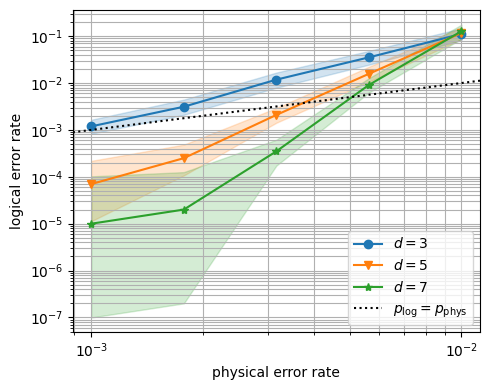

In [5]:
codes_to_simulate = [codes.ToricCode(dist, rotated=False) for dist in (3, 5, 7)]
decoding_kwargs = dict(
    with_BP_LSD=True, max_iter=30, bp_method="ms", lsd_method="lsd_cs", lsd_order=0
)
make_combined_memory_experiment_figure(codes_to_simulate, **decoding_kwargs)
plt.show()

### Bivariate bicycle codes

`BBCode`s come equipped with custom syndrome measurement circuits (inherited from the parent class, `QCCode`) that generalize the circuit for three-term `BBCode`s in Figure 5 of [arXiv:2308.07915v2](https://arxiv.org/abs/2308.07915v2).  Naturally, these simulations may take some time to run, though they could perhaps be sped up with a careful choice of decoder.

Note that numerical results here may differ slightly from those in [arXiv:2308.07915v2](https://arxiv.org/abs/2308.07915v2).  These differences can be attributed to (a) a different choice of decoder, and (b) that the results below account for the error rates of all logical operators, as opposed to only those of a fixed (X or Z) type.

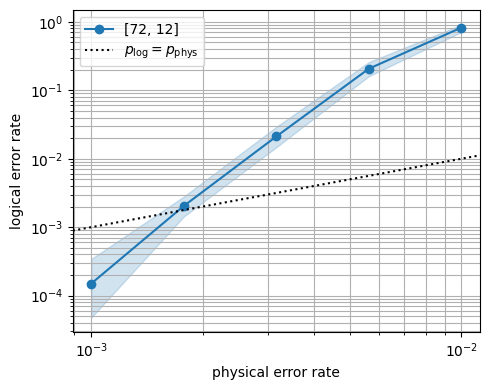

In [6]:
codes_to_simulate = [
    codes.BBCode(
        {x: 6, y: 6},
        x**3 + y + y**2,
        y**3 + x + x**2,
    ),
]
decoding_kwargs = dict(
    with_BP_LSD=True, max_iter=30, bp_method="ms", lsd_method="lsd_cs", lsd_order=0
)
make_combined_memory_experiment_figure(codes_to_simulate, **decoding_kwargs)
plt.show()